## Step 1: Problem Framing & Theory Notes

### 1. What is Regression? How is it different from Classification?

- **Regression** predicts a **continuous numeric** target (e.g. a price, a temperature, a duration).
- **Classification** predicts a **discrete category/label** (e.g. spam vs. not spam).
- The evaluation metrics differ: regression uses RMSE/MAE/R², classification uses accuracy/precision/recall.
- **Indian examples:**
  - Predicting the **EMI amount** a customer at HDFC/Bajaj Finance will pay based on loan amount, tenure, and interest rate — a regression problem (continuous EMI value).
  - Predicting **crop yield (tonnes/acre)** in Maharashtra based on rainfall, soil type, and fertilizer usage — a regression problem (continuous yield value).

### 2. Simple Linear Regression vs. Multiple Linear Regression vs. Regularized Regression (Ridge/Lasso)

- **Simple Linear Regression**: one input feature predicts the target, `y = b0 + b1*x`.
- **Multiple Linear Regression**: many input features predict the target, `y = b0 + b1*x1 + ... + bn*xn`.
- **Regularized Regression (Ridge/Lasso)**: adds a penalty term on the coefficients to the loss function to reduce overfitting.
  - **Ridge (L2)** shrinks coefficients toward zero but rarely to exactly zero.
  - **Lasso (L1)** can shrink coefficients to exactly zero, performing automatic feature selection.

### 3. Overfitting vs. Underfitting; How Regularization (L1/L2) Helps

- **Overfitting**: model learns noise in the training data — very low training error, high test error.
- **Underfitting**: model is too simple to capture the pattern — high error on both training and test data.
- **L1/L2 regularization** adds a penalty on large coefficients, discouraging the model from relying too heavily on any single feature, which reduces variance and helps overfitting.

### 4. RMSE, MAE, and R² — Definitions and When to Prefer RMSE over MAE

- **MAE (Mean Absolute Error)** = average of `|y_true - y_pred|`. Treats all errors linearly.
- **RMSE (Root Mean Squared Error)** = square root of the average of `(y_true - y_pred)^2`. Squaring **penalizes large errors more heavily**.
- **R² (Coefficient of Determination)** = proportion of variance in the target explained by the model (1.0 = perfect fit).
- **Prefer RMSE** when large errors (e.g. wildly mispricing an expensive house) are especially costly and should be penalized more than proportionally; prefer **MAE** when all errors should be weighted equally regardless of size.

### 5. Cross-Validation (k-Fold) — Why Preferred Over a Single Train/Test Split

- **k-Fold CV** splits the data into *k* folds, trains on *k-1* folds and validates on the remaining fold, repeating *k* times so every row is used for validation exactly once.
- It is preferred over a single split because it **uses the data more efficiently** and gives a **more robust estimate** of model performance (average ± std across folds) instead of one estimate that could be a lucky/unlucky split.


## Step 2: Dataset Loading & Exploratory Data Analysis

### 2.1 Load & Understand the Dataset


In [1]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# ------------------------------------------------------------
# Load the training dataset
# ------------------------------------------------------------
train = pd.read_csv("train.csv")

print("Dataset shape:", train.shape)


Dataset shape: (1460, 81)


In [2]:
# Dataset info: column dtypes, non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
# Statistical summary of numerical columns
train.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [4]:
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

missing_counts = train.isnull().sum()
missing_pct = (missing_counts / len(train) * 100).round(2)
cols_with_missing = missing_counts[missing_counts > 0].sort_values(ascending=False)

print(f"(a) Number of numerical columns   : {len(numerical_cols)}")
print(f"(b) Number of categorical columns : {len(categorical_cols)}")
print(f"(c) Number of columns with missing values : {len(cols_with_missing)}")
print("\nColumns with missing values (count / %):\n")
missing_summary = pd.DataFrame({"Missing_Count": cols_with_missing,
                                 "Missing_Percent": missing_pct.loc[cols_with_missing.index]})
missing_summary


(a) Number of numerical columns   : 38
(b) Number of categorical columns : 43
(c) Number of columns with missing values : 19

Columns with missing values (count / %):



C:\Users\Admin\AppData\Local\Temp\ipykernel_6704\895508503.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()


,Missing_Count,Missing_Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


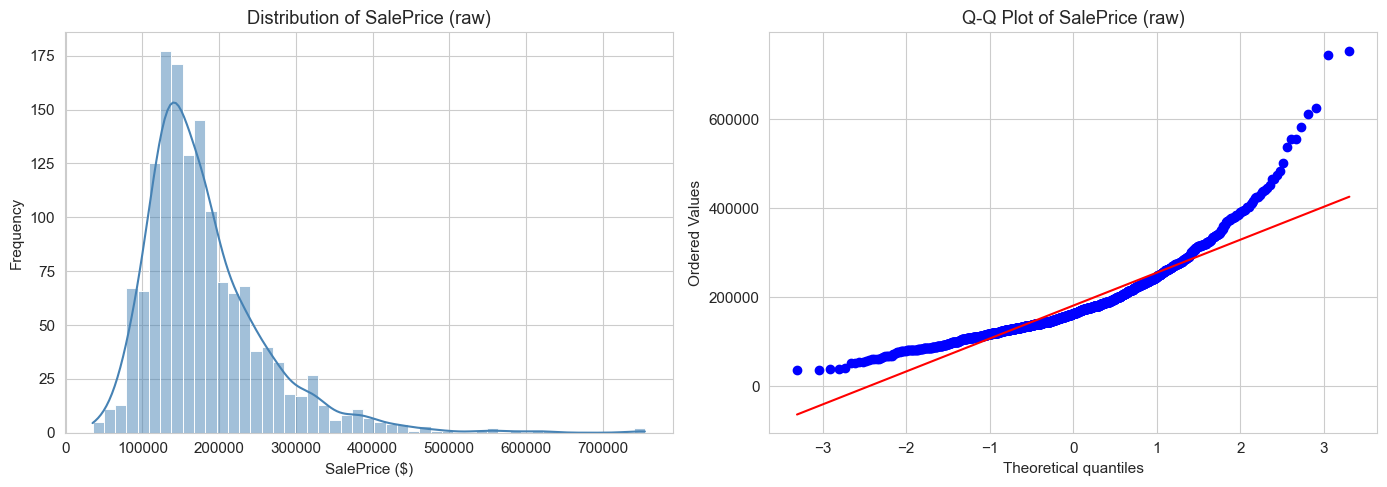

Skewness of raw SalePrice : 1.883
Kurtosis of raw SalePrice : 6.536


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of SalePrice (raw)")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Frequency")

stats.probplot(train["SalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of SalePrice (raw)")

plt.tight_layout()
plt.show()

print(f"Skewness of raw SalePrice : {train['SalePrice'].skew():.3f}")
print(f"Kurtosis of raw SalePrice : {train['SalePrice'].kurt():.3f}")


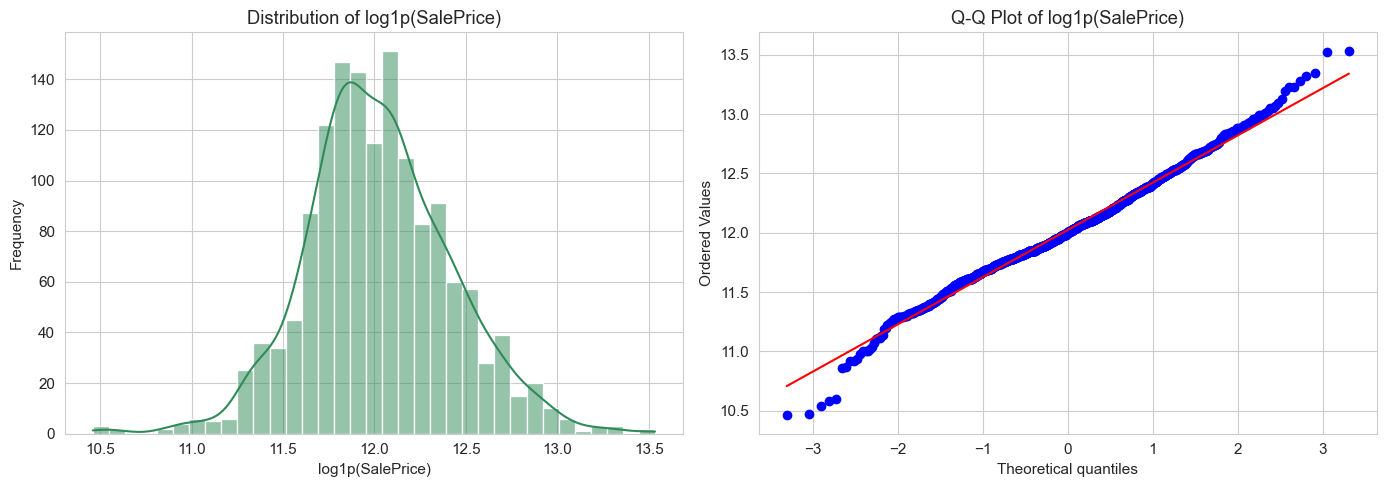

Skewness after log1p : 0.121
Kurtosis after log1p : 0.810


In [6]:
saleprice_log = np.log1p(train["SalePrice"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(saleprice_log, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Distribution of log1p(SalePrice)")
axes[0].set_xlabel("log1p(SalePrice)")
axes[0].set_ylabel("Frequency")

stats.probplot(saleprice_log, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of log1p(SalePrice)")

plt.tight_layout()
plt.show()

print(f"Skewness after log1p : {saleprice_log.skew():.3f}")
print(f"Kurtosis after log1p : {saleprice_log.kurt():.3f}")


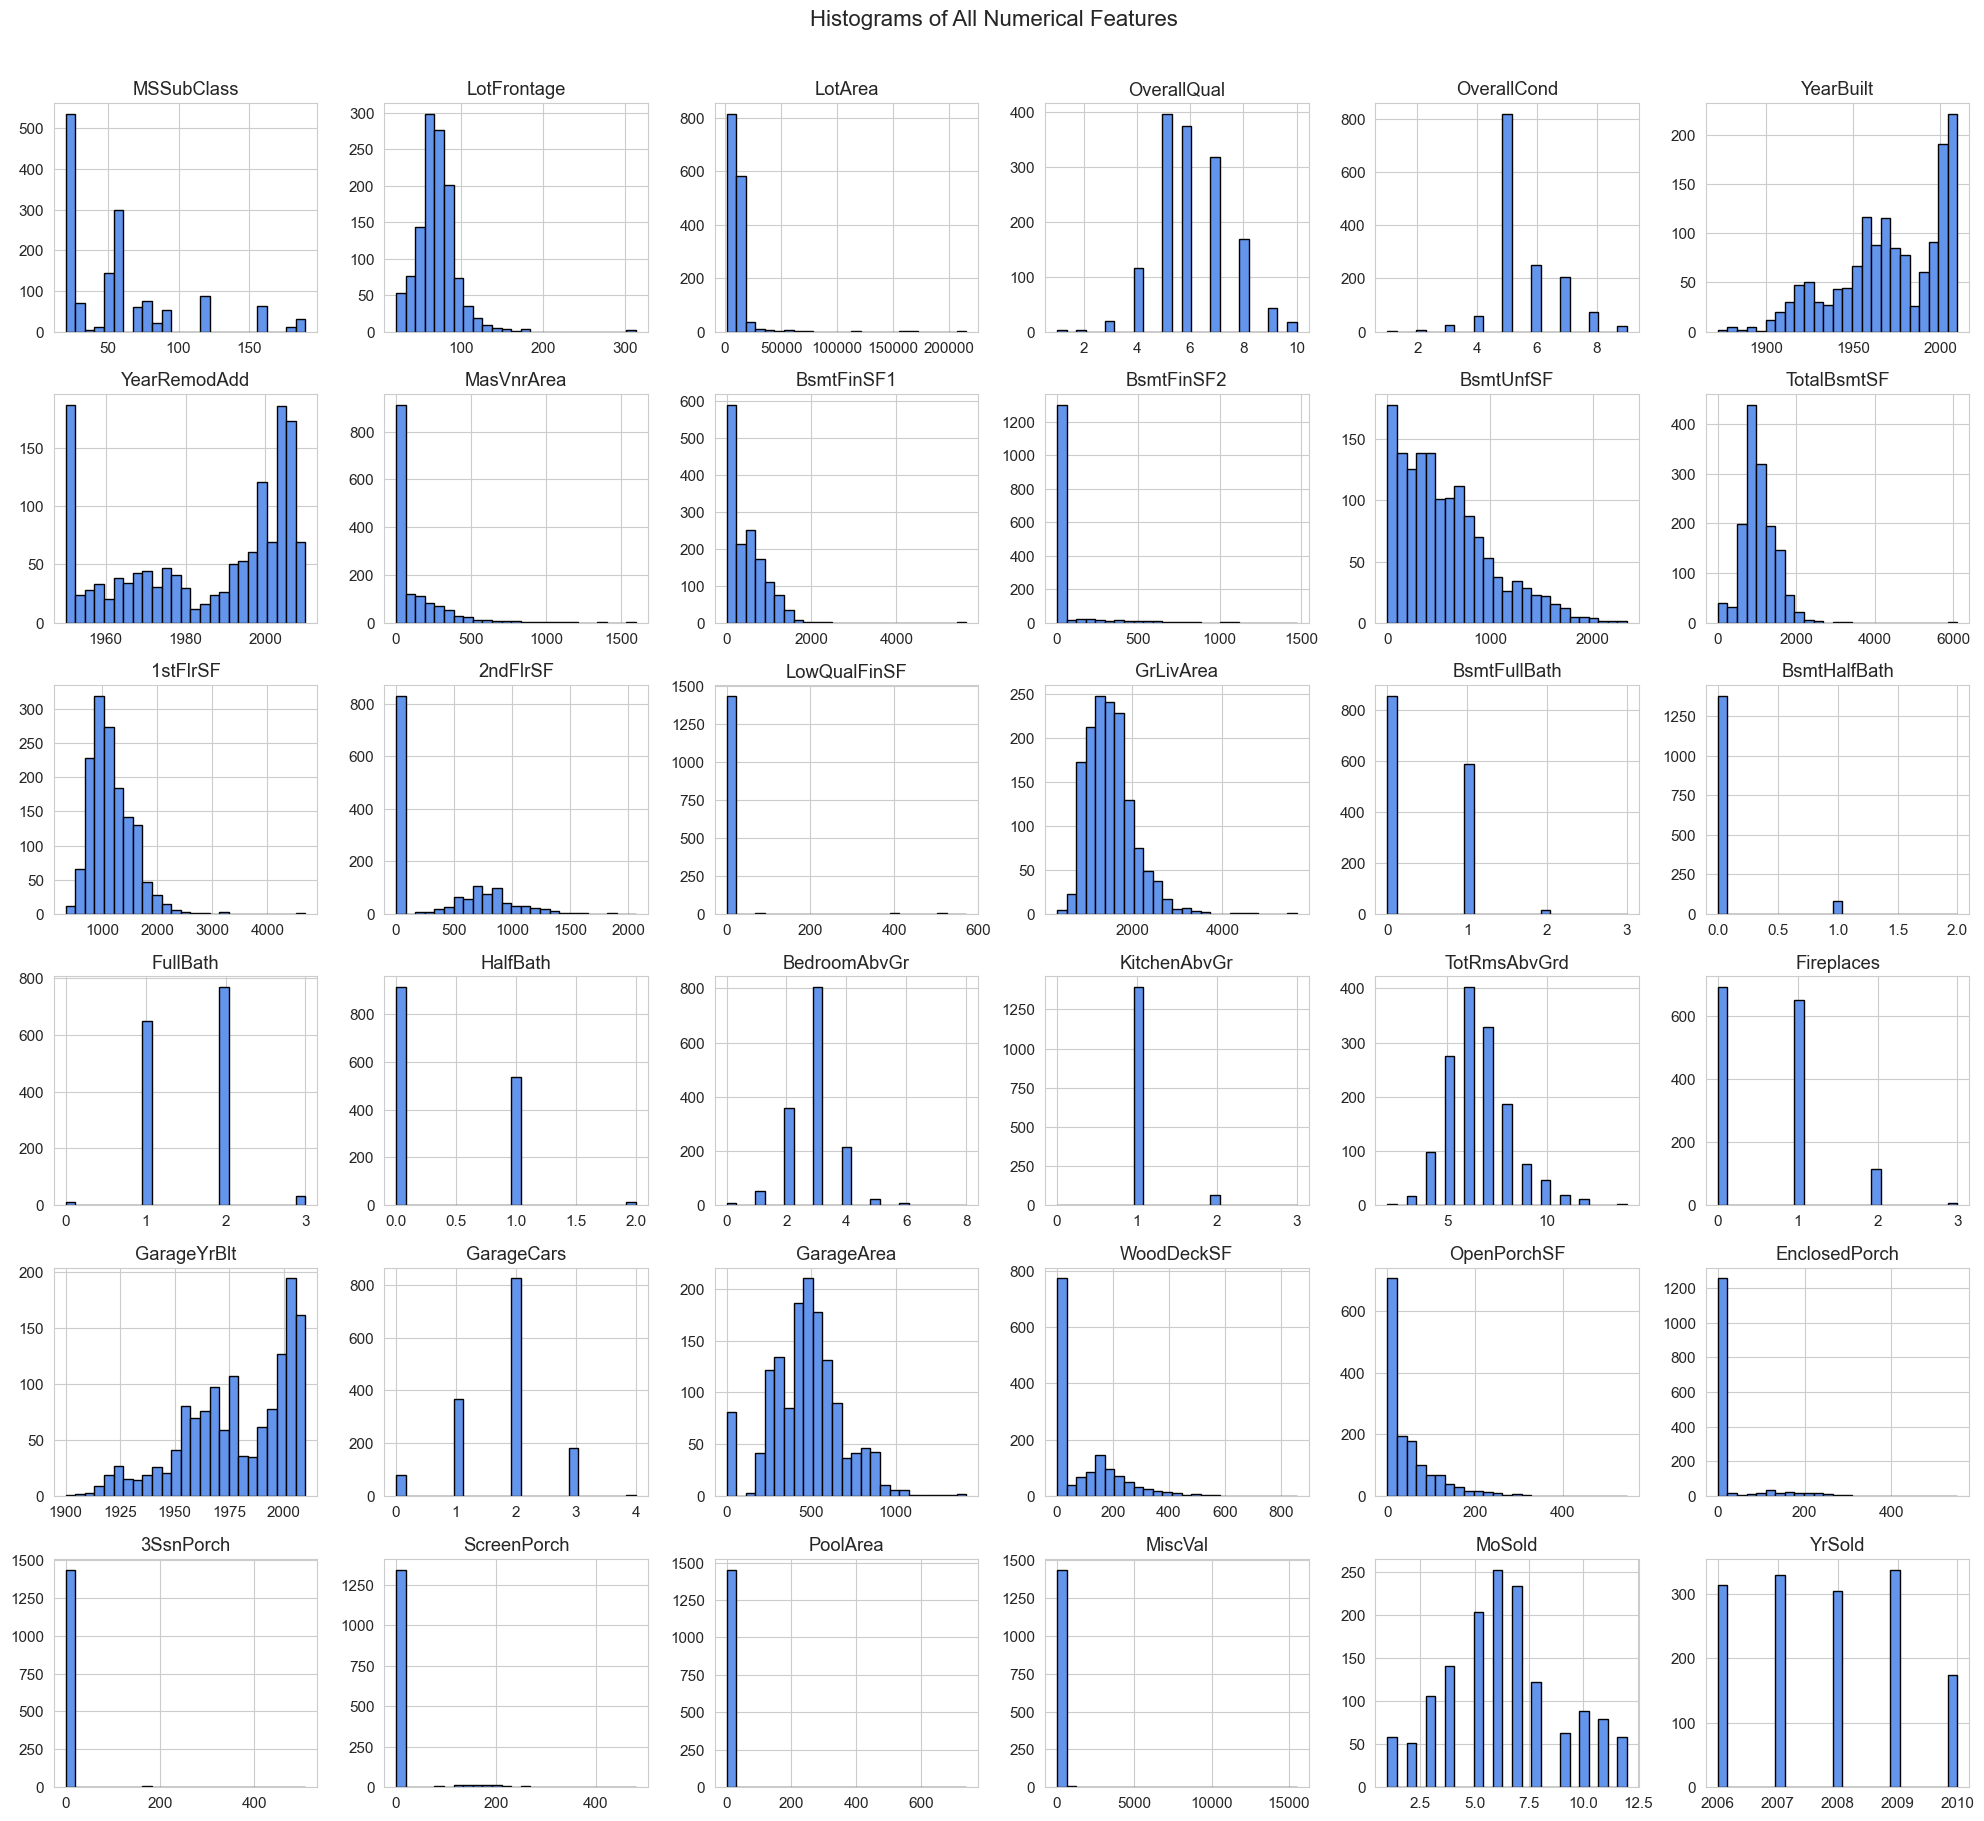

In [7]:
num_features = [c for c in numerical_cols if c not in ["Id", "SalePrice"]]

train[num_features].hist(bins=25, figsize=(20, 18), color="cornflowerblue", edgecolor="black")
plt.suptitle("Histograms of All Numerical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


Top 5 most skewed numerical columns:

MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


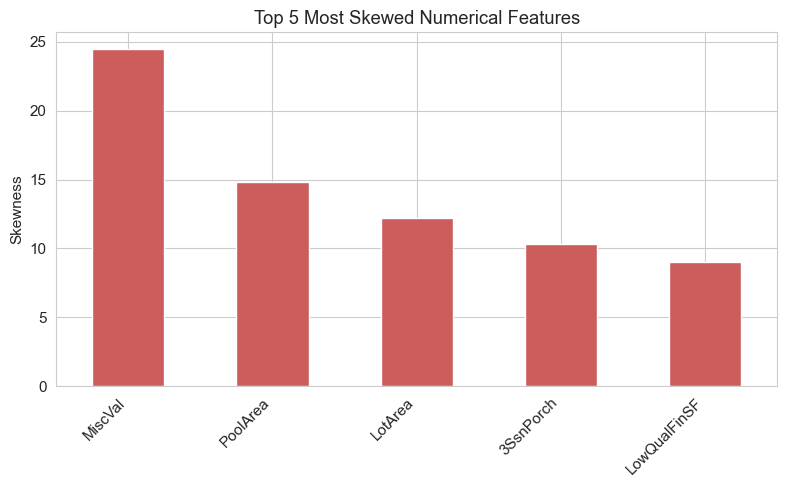

In [8]:
skewness = train[num_features].skew().sort_values(ascending=False)
top5_skewed = skewness.head(5)

print("Top 5 most skewed numerical columns:\n")
print(top5_skewed)

plt.figure(figsize=(8, 5))
top5_skewed.plot(kind="bar", color="indianred")
plt.title("Top 5 Most Skewed Numerical Features")
plt.ylabel("Skewness")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


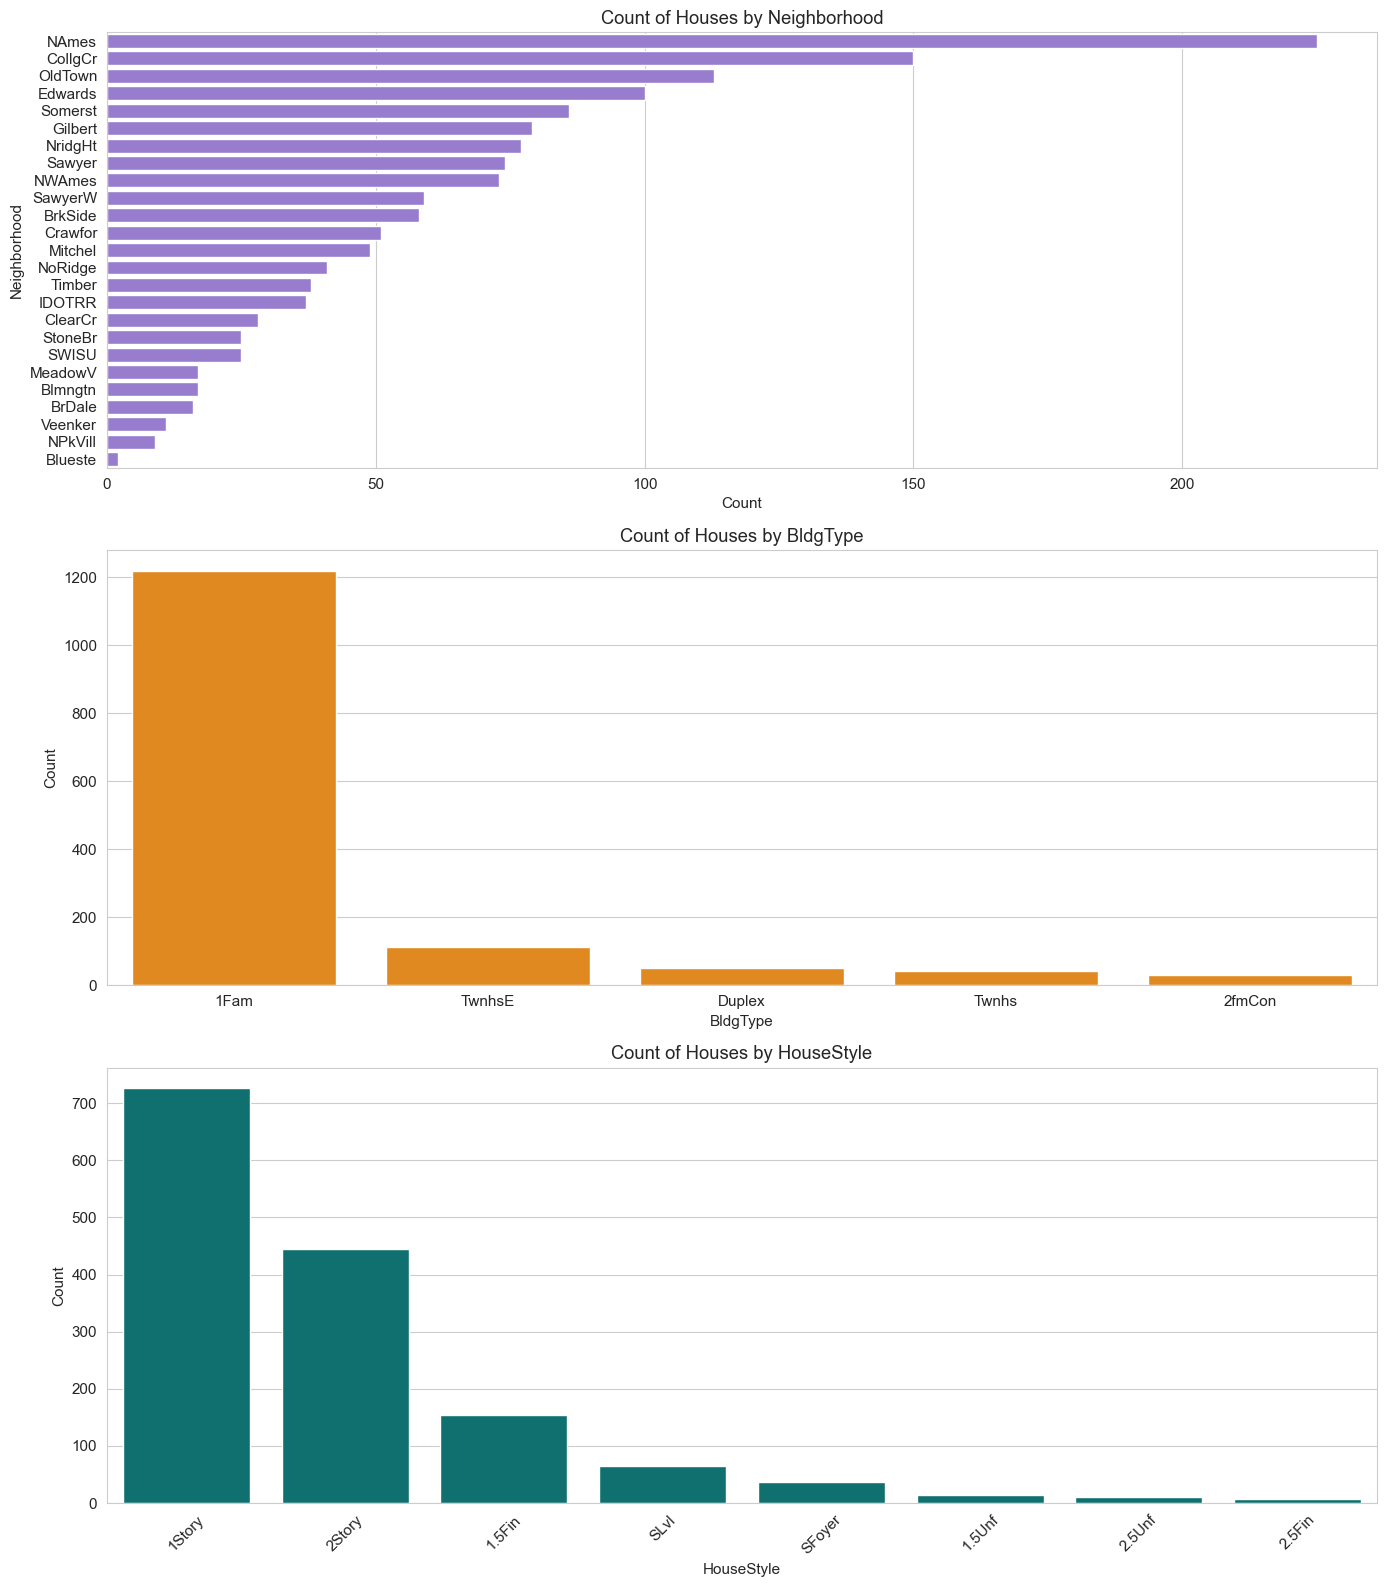

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

order_neigh = train["Neighborhood"].value_counts().index
sns.countplot(data=train, y="Neighborhood", order=order_neigh, ax=axes[0], color="mediumpurple")
axes[0].set_title("Count of Houses by Neighborhood")
axes[0].set_xlabel("Count")

order_bldg = train["BldgType"].value_counts().index
sns.countplot(data=train, x="BldgType", order=order_bldg, ax=axes[1], color="darkorange")
axes[1].set_title("Count of Houses by BldgType")
axes[1].set_ylabel("Count")

order_style = train["HouseStyle"].value_counts().index
sns.countplot(data=train, x="HouseStyle", order=order_style, ax=axes[2], color="teal")
axes[2].set_title("Count of Houses by HouseStyle")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


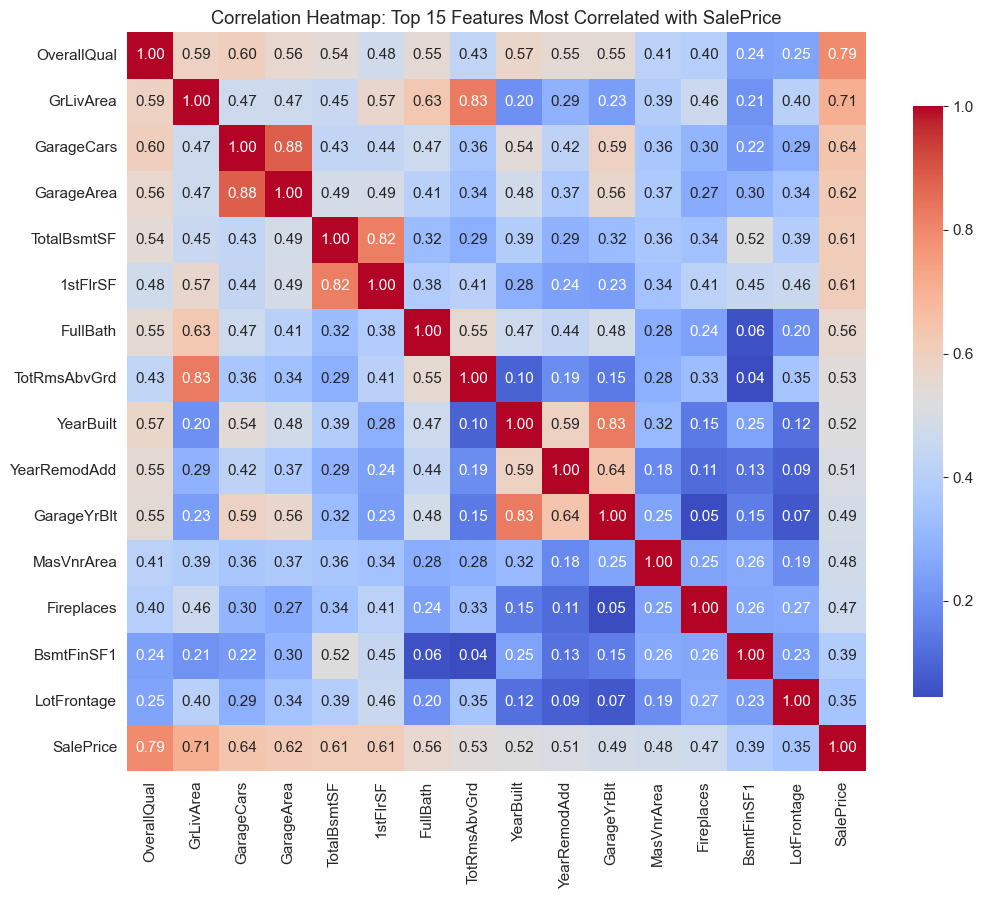

Top 15 features most correlated with SalePrice:

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64


In [10]:
corr_matrix = train[num_features + ["SalePrice"]].corr()
top15_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False)[1:16].index.tolist()

plt.figure(figsize=(11, 9))
sns.heatmap(train[top15_features + ["SalePrice"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap: Top 15 Features Most Correlated with SalePrice")
plt.tight_layout()
plt.show()

print("Top 15 features most correlated with SalePrice:\n")
print(corr_matrix["SalePrice"].abs().sort_values(ascending=False)[1:16])


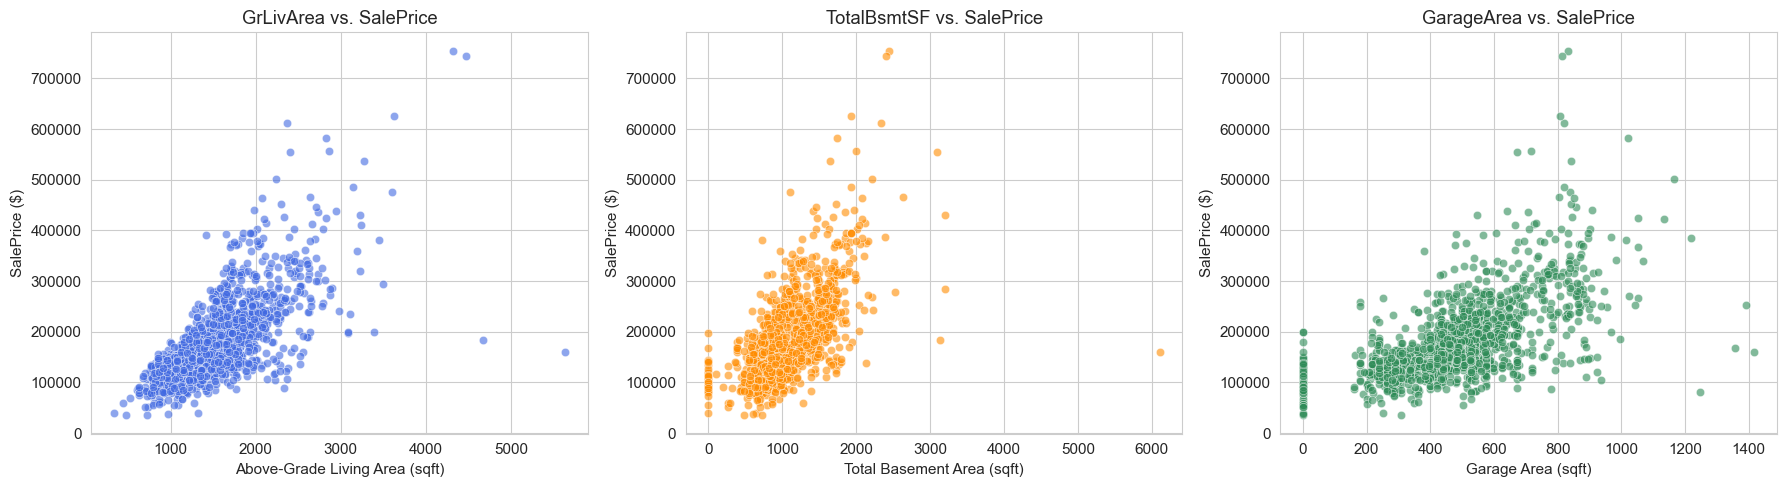

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", ax=axes[0], color="royalblue", alpha=0.6)
axes[0].set_title("GrLivArea vs. SalePrice")
axes[0].set_xlabel("Above-Grade Living Area (sqft)")
axes[0].set_ylabel("SalePrice ($)")

sns.scatterplot(data=train, x="TotalBsmtSF", y="SalePrice", ax=axes[1], color="darkorange", alpha=0.6)
axes[1].set_title("TotalBsmtSF vs. SalePrice")
axes[1].set_xlabel("Total Basement Area (sqft)")
axes[1].set_ylabel("SalePrice ($)")

sns.scatterplot(data=train, x="GarageArea", y="SalePrice", ax=axes[2], color="seagreen", alpha=0.6)
axes[2].set_title("GarageArea vs. SalePrice")
axes[2].set_xlabel("Garage Area (sqft)")
axes[2].set_ylabel("SalePrice ($)")

plt.tight_layout()
plt.show()


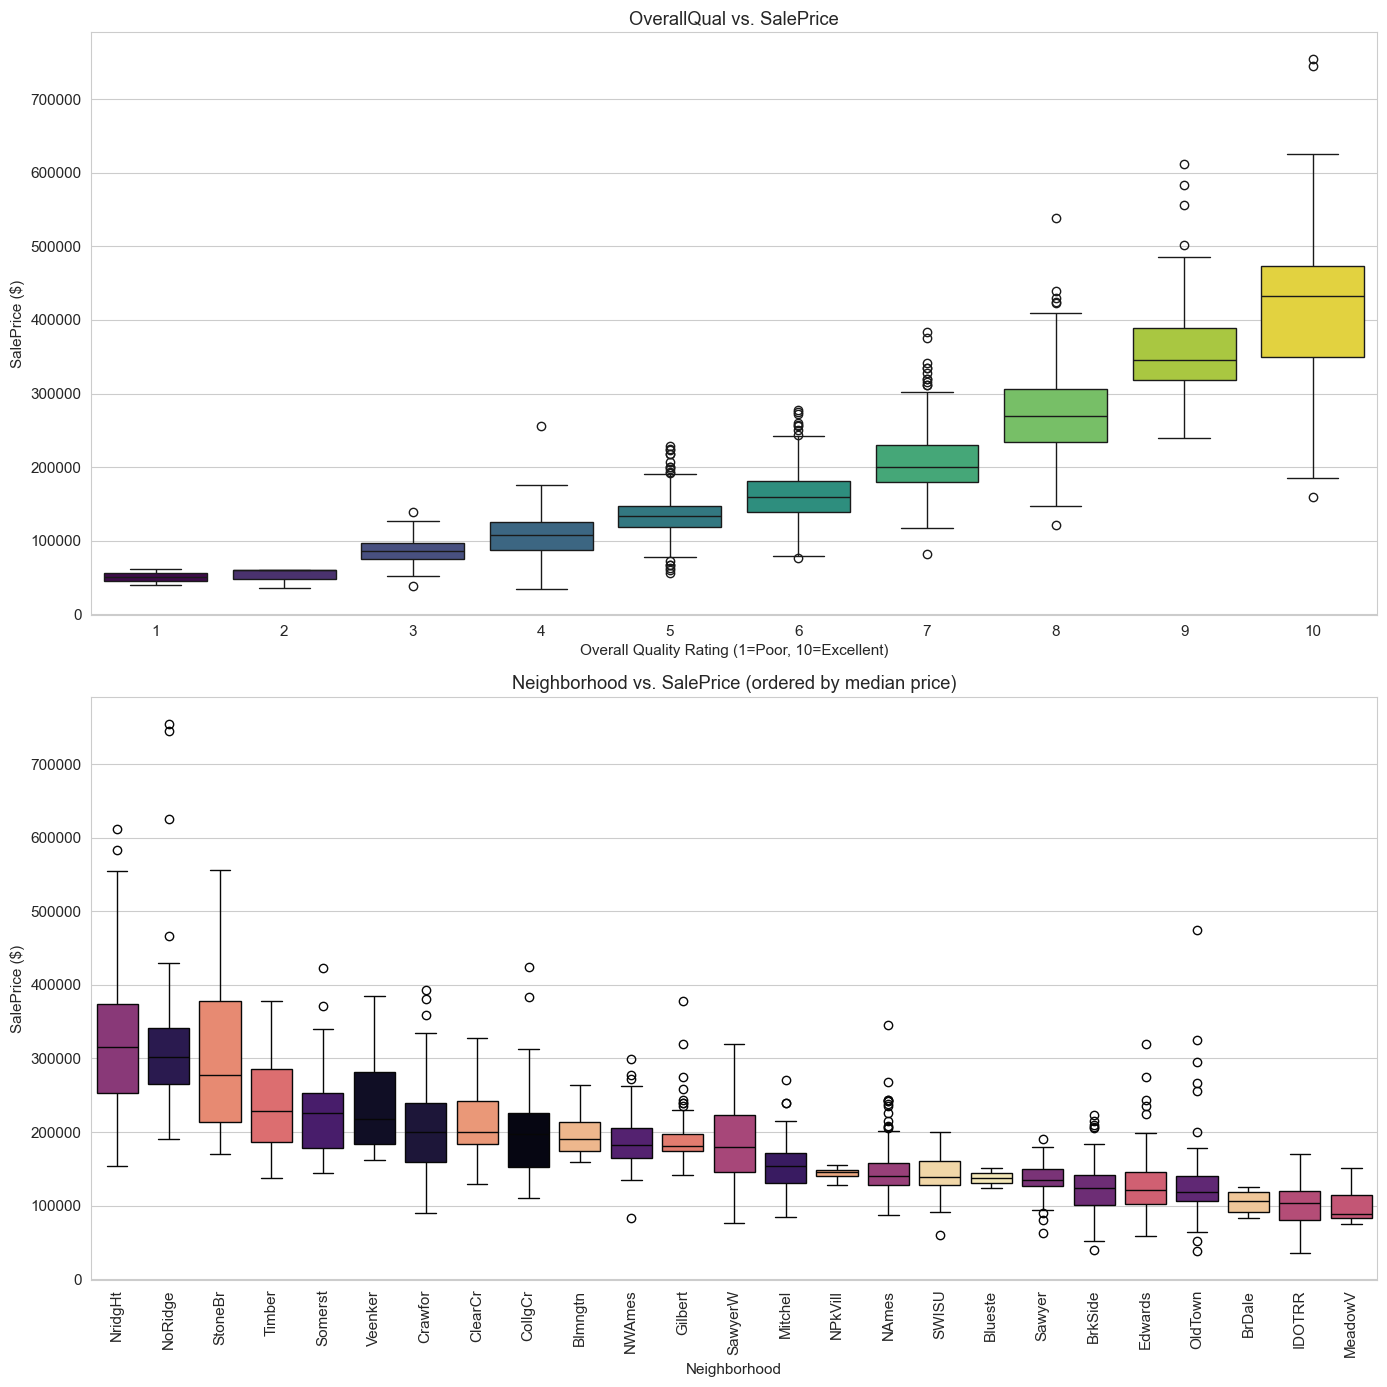

Priciest neighborhood (by median SalePrice): NridgHt


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

sns.boxplot(data=train, x="OverallQual", y="SalePrice", ax=axes[0], hue="OverallQual",
            palette="viridis", legend=False)
axes[0].set_title("OverallQual vs. SalePrice")
axes[0].set_xlabel("Overall Quality Rating (1=Poor, 10=Excellent)")
axes[0].set_ylabel("SalePrice ($)")

neigh_order = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=neigh_order, ax=axes[1],
            hue="Neighborhood", palette="magma", legend=False)
axes[1].set_title("Neighborhood vs. SalePrice (ordered by median price)")
axes[1].set_xlabel("Neighborhood")
axes[1].set_ylabel("SalePrice ($)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

priciest_neigh = train.groupby("Neighborhood")["SalePrice"].median().idxmax()
print(f"Priciest neighborhood (by median SalePrice): {priciest_neigh}")


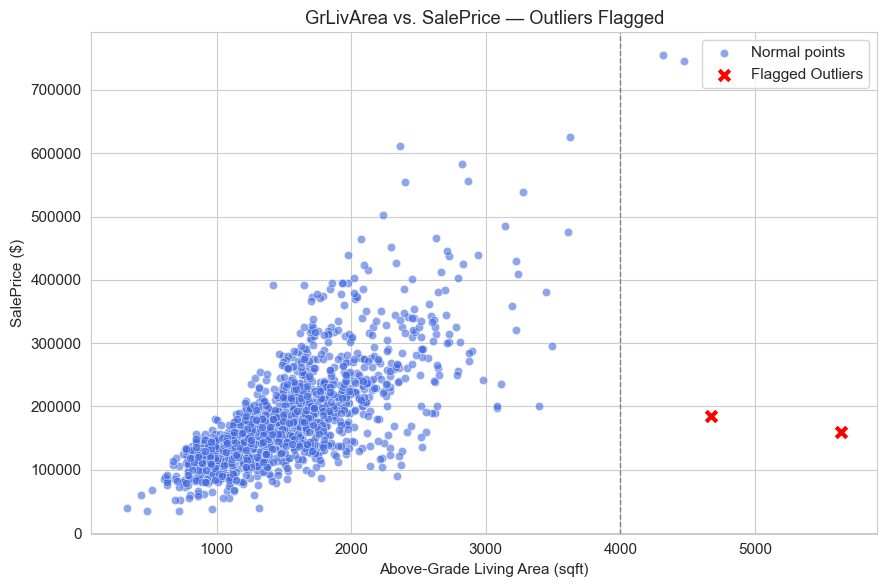

Flagged outlier rows:


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [13]:
# ------------------------------------------------------------
# Identify and flag outliers in GrLivArea vs. SalePrice
# ------------------------------------------------------------
outlier_condition = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
outliers = train.loc[outlier_condition, ["Id", "GrLivArea", "SalePrice"]]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", color="royalblue", alpha=0.6, label="Normal points")
sns.scatterplot(data=train[outlier_condition], x="GrLivArea", y="SalePrice", color="red", s=120,
                marker="X", label="Flagged Outliers")
plt.axvline(4000, color="gray", linestyle="--", linewidth=1)
plt.title("GrLivArea vs. SalePrice — Outliers Flagged")
plt.xlabel("Above-Grade Living Area (sqft)")
plt.ylabel("SalePrice ($)")
plt.legend()
plt.tight_layout()
plt.show()

print("Flagged outlier rows:")
outliers


## Step 3: Data Preprocessing & Feature Engineering

### 3.1 Handle Missing Values

Strategy (per the data dictionary in `data_description.txt`):
- **Categorical columns where `NaN` means "None"** (e.g. `PoolQC`, `Fence`, `GarageType`, `Alley`, `MiscFeature`, `FireplaceQu`, basement/garage quality columns) → fill with the string `'None'`.
- **Numerical columns where `NaN` means 0** (e.g. `GarageArea`, `BsmtFinSF1`, `GarageCars`, `MasVnrArea`) → fill with `0`.
- **Remaining numerical columns** (e.g. `LotFrontage`) → fill with the **median**.
- **Columns with >80% missing values** → dropped entirely.


In [14]:
# Work on a copy so the original raw dataframe stays untouched for reference
df = train.copy()

missing_report = (df.isnull().sum() / len(df) * 100).round(2)
missing_report = missing_report[missing_report > 0].sort_values(ascending=False)
print("Missing value % per column (before handling):\n")
print(missing_report)


Missing value % per column (before handling):

PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
BsmtExposure     2.60
BsmtFinType2     2.60
BsmtQual         2.53
BsmtCond         2.53
BsmtFinType1     2.53
MasVnrArea       0.55
Electrical       0.07
dtype: float64


In [15]:
none_fill_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
                   "GarageType", "GarageFinish", "GarageQual", "GarageCond",
                   "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                   "MasVnrType"]
none_fill_cols = [c for c in none_fill_cols if c in df.columns]
df[none_fill_cols] = df[none_fill_cols].fillna("None")

zero_fill_cols = ["GarageYrBlt", "GarageArea", "GarageCars",
                   "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
                   "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
zero_fill_cols = [c for c in zero_fill_cols if c in df.columns]
df[zero_fill_cols] = df[zero_fill_cols].fillna(0)

missing_pct_now = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct_now[missing_pct_now > 80].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f"Columns dropped (>80% missing): {cols_to_drop}")

remaining_num = df.select_dtypes(include=[np.number]).columns
remaining_num = [c for c in remaining_num if c not in ["Id", "SalePrice"]]
for col in remaining_num:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

remaining_cat = df.select_dtypes(include=["object"]).columns
for col in remaining_cat:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nRemaining missing values after full handling: {df.isnull().sum().sum()}")


Columns dropped (>80% missing): []

Remaining missing values after full handling: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_6704\3053759105.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat = df.select_dtypes(include=["object"]).columns


In [16]:
before_rows = df.shape[0]
outlier_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)
print(f"Rows flagged as outliers: {outlier_mask.sum()}")

df = df.loc[~outlier_mask].reset_index(drop=True)
after_rows = df.shape[0]

print(f"Rows before removal : {before_rows}")
print(f"Rows after removal  : {after_rows}")


Rows flagged as outliers: 2
Rows before removal : 1460
Rows after removal  : 1458


In [17]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["HasPool"] = (df["PoolArea"] > 0).astype(int)

print(df[["TotalSF", "HouseAge", "RemodAge", "HasGarage", "HasPool"]].describe())


           TotalSF     HouseAge     RemodAge    HasGarage      HasPool
count  1458.000000  1458.000000  1458.000000  1458.000000  1458.000000
mean   2557.150206    36.598080    22.982167     0.944444     0.004115
std     774.109803    30.240565    20.636501     0.229140     0.064040
min     334.000000     0.000000     0.000000     0.000000     0.000000
25%    2008.500000     8.000000     4.000000     1.000000     0.000000
50%    2473.000000    35.000000    14.000000     1.000000     0.000000
75%    3002.250000    54.000000    41.000000     1.000000     0.000000
max    6872.000000   136.000000    60.000000     1.000000     1.000000


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, FunctionTransformer

# 1) Quality/condition columns -> fixed-order ordinal encoding
quality_cols = ["ExterQual", "KitchenQual", "BsmtQual", "FireplaceQu"]
quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]  # maps to 0,1,2,3,4,5

# 2) Neighborhood -> label/ordinal encoding (high cardinality)
neighborhood_col = ["Neighborhood"]

# 3) Remaining nominal categorical columns with <=10 unique values -> one-hot encoding
categorical_all = df.select_dtypes(include=["object"]).columns.tolist()
nominal_cols = [c for c in categorical_all
                if c not in quality_cols + neighborhood_col
                and df[c].nunique() <= 10]

# Any leftover high-cardinality categorical columns (not Neighborhood) are dropped
# to keep the encoding scheme exactly as specified in the exam paper.
leftover_cat_cols = [c for c in categorical_all
                      if c not in quality_cols + neighborhood_col + nominal_cols]

# 4) Numerical (continuous) columns
exclude_cols = ["Id", "SalePrice"] + quality_cols + neighborhood_col + nominal_cols + leftover_cat_cols
numeric_final_cols = [c for c in df.columns if c not in exclude_cols
                       and df[c].dtype != "object"]

# Identify skewed numeric columns (skewness > 0.75) among the continuous features
skew_vals = df[numeric_final_cols].skew()
skewed_cols = skew_vals[skew_vals.abs() > 0.75].index.tolist()
normal_num_cols = [c for c in numeric_final_cols if c not in skewed_cols]

print(f"Ordinal (quality) columns   : {quality_cols}")
print(f"Label-encoded column        : {neighborhood_col}")
print(f"One-hot columns ({len(nominal_cols)})       : {nominal_cols}")
print(f"Dropped high-card. columns   : {leftover_cat_cols}")
print(f"Log1p + scale columns ({len(skewed_cols)}) : {skewed_cols}")
print(f"Scale-only columns ({len(normal_num_cols)})  : {normal_num_cols}")


Ordinal (quality) columns   : ['ExterQual', 'KitchenQual', 'BsmtQual', 'FireplaceQu']
Label-encoded column        : ['Neighborhood']
One-hot columns (36)       : ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Dropped high-card. columns   : ['Exterior1st', 'Exterior2nd']
Log1p + scale columns (24) : ['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'GarageYrBlt', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'

C:\Users\Admin\AppData\Local\Temp\ipykernel_6704\1144420996.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_all = df.select_dtypes(include=["object"]).columns.tolist()


In [19]:
# Pipeline for skewed numeric features: log1p transform, then scale
skewed_pipeline = Pipeline(steps=[
    ("log1p", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

# Pipeline for the remaining (non-skewed) numeric features: scale only
normal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Ordinal pipeline for the fixed-order quality columns
quality_pipeline = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(categories=[quality_order] * len(quality_cols)))
])

# Ordinal (label) pipeline for Neighborhood
neighborhood_pipeline = Pipeline(steps=[
    ("ordinal", OrdinalEncoder())
])

# One-hot pipeline for low-cardinality nominal columns
onehot_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("skewed_num", skewed_pipeline, skewed_cols),
    ("normal_num", normal_pipeline, normal_num_cols),
    ("quality_ord", quality_pipeline, quality_cols),
    ("neighborhood_ord", neighborhood_pipeline, neighborhood_col),
    ("nominal_ohe", onehot_pipeline, nominal_cols),
], remainder="drop")

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_num', ...), ('normal_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [20]:
from sklearn.model_selection import train_test_split

y = np.log1p(df["SalePrice"])

# Feature matrix: every column the ColumnTransformer above expects
feature_cols = skewed_cols + normal_num_cols + quality_cols + neighborhood_col + nominal_cols
X = df[feature_cols].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")


X_train shape : (1166, 82)
X_test shape  : (292, 82)
y_train shape : (1166,)
y_test shape  : (292,)


## Step 4: Regression Models — Linear, Ridge & Lasso

All models below are trained on the **preprocessed** feature matrix produced by the
`preprocessor` `ColumnTransformer` built in Step 3.4 (fit on `X_train` only, then applied
to both `X_train` and `X_test` — no leakage), predicting the **log1p(SalePrice)** target
from Step 3.5. Every reported RMSE/MAE/R² is computed **after `np.expm1()`** is applied to
both the true values and the predictions, so all metrics are in **original USD units**.


In [21]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Reconstruct feature names in the exact order the ColumnTransformer emits them
# (skewed_num -> normal_num -> quality_ord -> neighborhood_ord -> nominal_ohe)
onehot_feature_names = list(
    preprocessor.named_transformers_["nominal_ohe"].named_steps["onehot"].get_feature_names_out(nominal_cols)
)
feature_names = skewed_cols + normal_num_cols + quality_cols + neighborhood_col + onehot_feature_names

print(f"X_train_proc shape : {X_train_proc.shape}")
print(f"X_test_proc shape  : {X_test_proc.shape}")
print(f"Feature names built: {len(feature_names)}")
assert X_train_proc.shape[1] == len(feature_names), "Feature name / column count mismatch!"


X_train_proc shape : (1166, 233)
X_test_proc shape  : (292, 233)
Feature names built: 233


In [22]:
def usd_metrics(y_true_log, y_pred_log):
    '''Reverse the log1p target transform and compute RMSE, MAE, R2 in USD.'''
    y_true_usd = np.expm1(y_true_log)
    y_pred_usd = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    mae = mean_absolute_error(y_true_usd, y_pred_usd)
    r2 = r2_score(y_true_usd, y_pred_usd)
    return rmse, mae, r2, y_true_usd, y_pred_usd


# Custom scorer used later for cross-validation so CV RMSE is also on the USD scale
def _rmse_usd_scoring(y_true_log, y_pred_log):
    rmse, _, _, _, _ = usd_metrics(y_true_log, y_pred_log)
    return rmse

rmse_usd_scorer = make_scorer(_rmse_usd_scoring, greater_is_better=False)

# Dictionary to accumulate results for the Step 6 comparison table
results = {}


### 4.1 Linear Regression (Baseline)

In [23]:
from sklearn.linear_model import LinearRegression

start = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_proc, y_train)
lin_train_time = time.time() - start

y_pred_log = lin_reg.predict(X_test_proc)
lin_rmse, lin_mae, lin_r2, y_test_usd, lin_pred_usd = usd_metrics(y_test, y_pred_log)

results["Linear Regression"] = {"RMSE": lin_rmse, "MAE": lin_mae, "R2": lin_r2,
                                 "CV_RMSE": np.nan, "Train_Time_s": lin_train_time}

print("Linear Regression (test set, original USD scale)")
print(f"  RMSE : ${lin_rmse:,.0f}")
print(f"  MAE  : ${lin_mae:,.0f}")
print(f"  R2   : {lin_r2:.4f}")


Linear Regression (test set, original USD scale)
  RMSE : $23,428
  MAE  : $16,087
  R2   : 0.9006


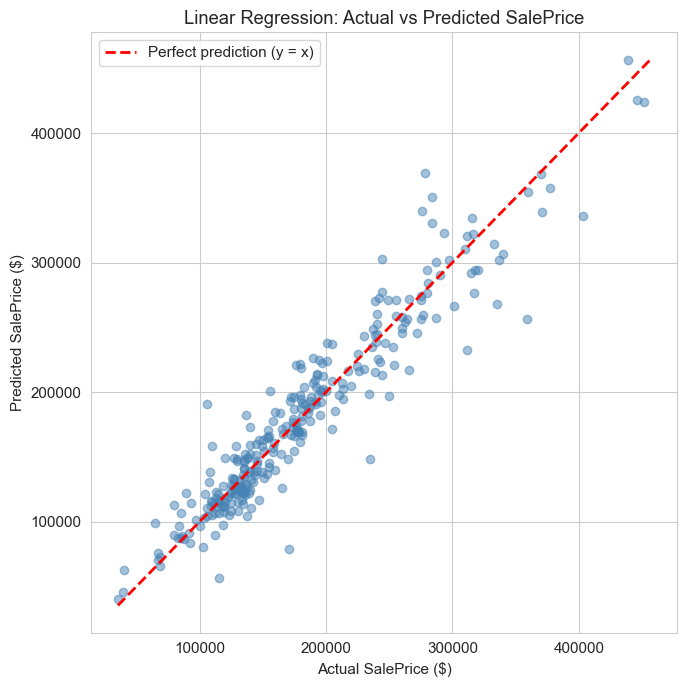

In [24]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test_usd, lin_pred_usd, alpha=0.5, color="steelblue")
lims = [min(y_test_usd.min(), lin_pred_usd.min()), max(y_test_usd.max(), lin_pred_usd.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction (y = x)")
plt.xlabel("Actual SalePrice ($)")
plt.ylabel("Predicted SalePrice ($)")
plt.title("Linear Regression: Actual vs Predicted SalePrice")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
from sklearn.linear_model import RidgeCV

ridge_alphas = [0.01, 0.1, 1, 10, 100]

start = time.time()
ridge = RidgeCV(alphas=ridge_alphas, cv=5)
ridge.fit(X_train_proc, y_train)
ridge_train_time = time.time() - start

print(f"Best Ridge alpha selected: {ridge.alpha_}")

y_pred_log = ridge.predict(X_test_proc)
ridge_rmse, ridge_mae, ridge_r2, _, ridge_pred_usd = usd_metrics(y_test, y_pred_log)

results["Ridge"] = {"RMSE": ridge_rmse, "MAE": ridge_mae, "R2": ridge_r2,
                     "CV_RMSE": np.nan, "Train_Time_s": ridge_train_time}

print("\nRidge Regression (test set, original USD scale)")
print(f"  RMSE : ${ridge_rmse:,.0f}")
print(f"  MAE  : ${ridge_mae:,.0f}")
print(f"  R2   : {ridge_r2:.4f}")


Best Ridge alpha selected: 10.0

Ridge Regression (test set, original USD scale)
  RMSE : $20,583
  MAE  : $14,694
  R2   : 0.9233


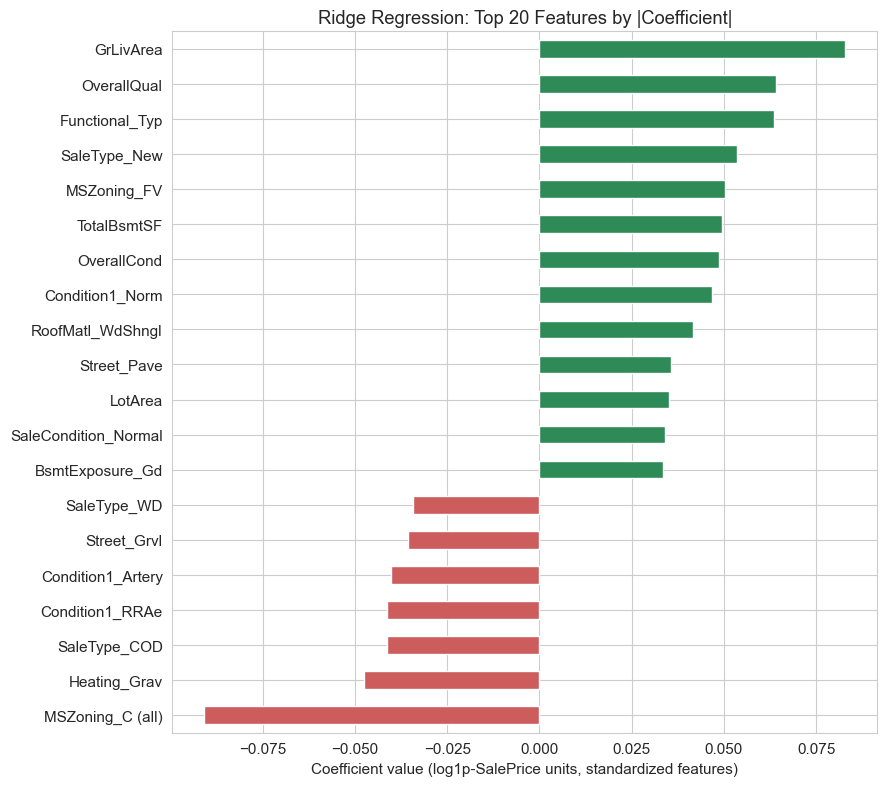

In [26]:
# Top 20 most impactful features by absolute coefficient value
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)
top20_ridge = ridge_coefs.reindex(ridge_coefs.abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(9, 8))
top20_ridge.sort_values().plot(kind="barh", color=np.where(top20_ridge.sort_values() >= 0, "seagreen", "indianred"))
plt.title("Ridge Regression: Top 20 Features by |Coefficient|")
plt.xlabel("Coefficient value (log1p-SalePrice units, standardized features)")
plt.tight_layout()
plt.show()


In [27]:
from sklearn.linear_model import LassoCV

lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1]

start = time.time()
lasso = LassoCV(alphas=lasso_alphas, max_iter=10000, cv=5, random_state=42)
lasso.fit(X_train_proc, y_train)
lasso_train_time = time.time() - start

n_zeroed = int(np.sum(lasso.coef_ == 0))
print(f"Best Lasso alpha selected  : {lasso.alpha_}")
print(f"Features zeroed out (coef = 0) : {n_zeroed} / {len(lasso.coef_)}")

y_pred_log = lasso.predict(X_test_proc)
lasso_rmse, lasso_mae, lasso_r2, _, lasso_pred_usd = usd_metrics(y_test, y_pred_log)

results["Lasso"] = {"RMSE": lasso_rmse, "MAE": lasso_mae, "R2": lasso_r2,
                     "CV_RMSE": np.nan, "Train_Time_s": lasso_train_time}

print("\nLasso Regression (test set, original USD scale)")
print(f"  RMSE : ${lasso_rmse:,.0f}")
print(f"  MAE  : ${lasso_mae:,.0f}")
print(f"  R2   : {lasso_r2:.4f}")


Best Lasso alpha selected  : 0.001
Features zeroed out (coef = 0) : 162 / 233

Lasso Regression (test set, original USD scale)
  RMSE : $20,121
  MAE  : $14,683
  R2   : 0.9267


In [28]:
print(f"{'Model':<10}{'RMSE ($)':>14}{'MAE ($)':>14}{'R2':>10}")
print(f"{'Ridge':<10}{ridge_rmse:>14,.0f}{ridge_mae:>14,.0f}{ridge_r2:>10.4f}")
print(f"{'Lasso':<10}{lasso_rmse:>14,.0f}{lasso_mae:>14,.0f}{lasso_r2:>10.4f}")


Model           RMSE ($)       MAE ($)        R2
Ridge             20,583        14,694    0.9233
Lasso             20,121        14,683    0.9267


In [29]:
step4_summary = pd.DataFrame(results).T[["RMSE", "MAE", "R2", "Train_Time_s"]]
step4_summary


,RMSE,MAE,R2,Train_Time_s
Linear Regression,23427.740741,16087.008658,0.900636,0.024497
Ridge,20583.378396,14693.728169,0.923299,0.120851
Lasso,20121.281388,14682.799646,0.926704,0.170252


## Step 5: Advanced Models — Random Forest & XGBoost Regressor

### 5.1 Random Forest Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor

start = time.time()
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_proc, y_train)
rf_train_time = time.time() - start

y_pred_log = rf_model.predict(X_test_proc)
rf_rmse, rf_mae, rf_r2, _, rf_pred_usd = usd_metrics(y_test, y_pred_log)

results["Random Forest"] = {"RMSE": rf_rmse, "MAE": rf_mae, "R2": rf_r2,
                             "CV_RMSE": np.nan, "Train_Time_s": rf_train_time}

print("Random Forest Regressor (test set, original USD scale)")
print(f"  RMSE : ${rf_rmse:,.0f}")
print(f"  MAE  : ${rf_mae:,.0f}")
print(f"  R2   : {rf_r2:.4f}")


Random Forest Regressor (test set, original USD scale)
  RMSE : $23,161
  MAE  : $16,334
  R2   : 0.9029


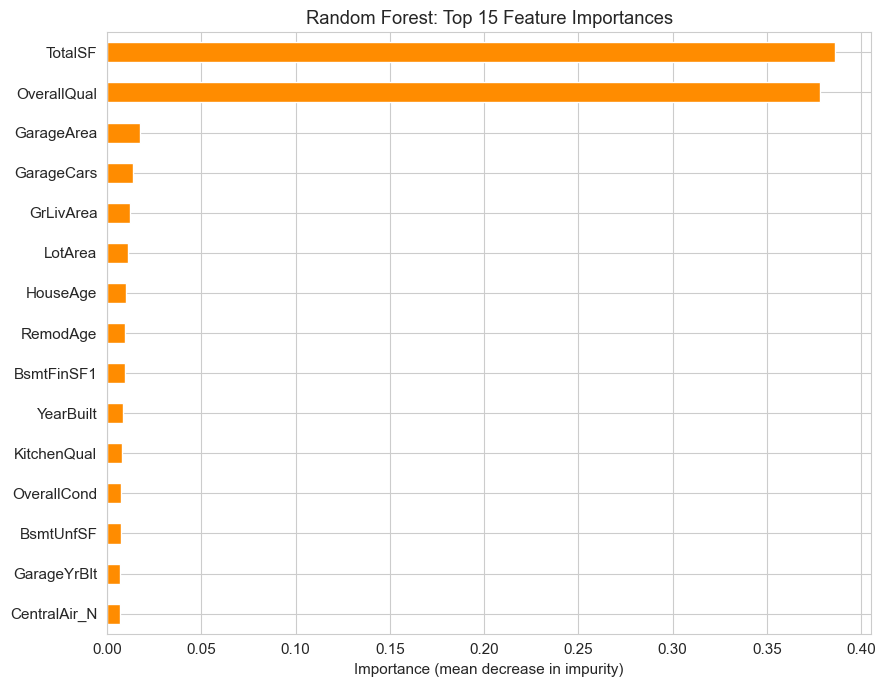

In [31]:
# Top 15 feature importances
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top15_rf = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
top15_rf.sort_values().plot(kind="barh", color="darkorange")
plt.title("Random Forest: Top 15 Feature Importances")
plt.xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.show()


In [32]:
from xgboost import XGBRegressor

start = time.time()
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train_proc, y_train)
xgb_train_time = time.time() - start

y_pred_log = xgb_model.predict(X_test_proc)
xgb_rmse, xgb_mae, xgb_r2, _, xgb_pred_usd = usd_metrics(y_test, y_pred_log)

results["XGBoost"] = {"RMSE": xgb_rmse, "MAE": xgb_mae, "R2": xgb_r2,
                       "CV_RMSE": np.nan, "Train_Time_s": xgb_train_time}

print("XGBoost Regressor (test set, original USD scale)")
print(f"  RMSE : ${xgb_rmse:,.0f}")
print(f"  MAE  : ${xgb_mae:,.0f}")
print(f"  R2   : {xgb_r2:.4f}")


XGBoost Regressor (test set, original USD scale)
  RMSE : $19,282
  MAE  : $14,218
  R2   : 0.9327


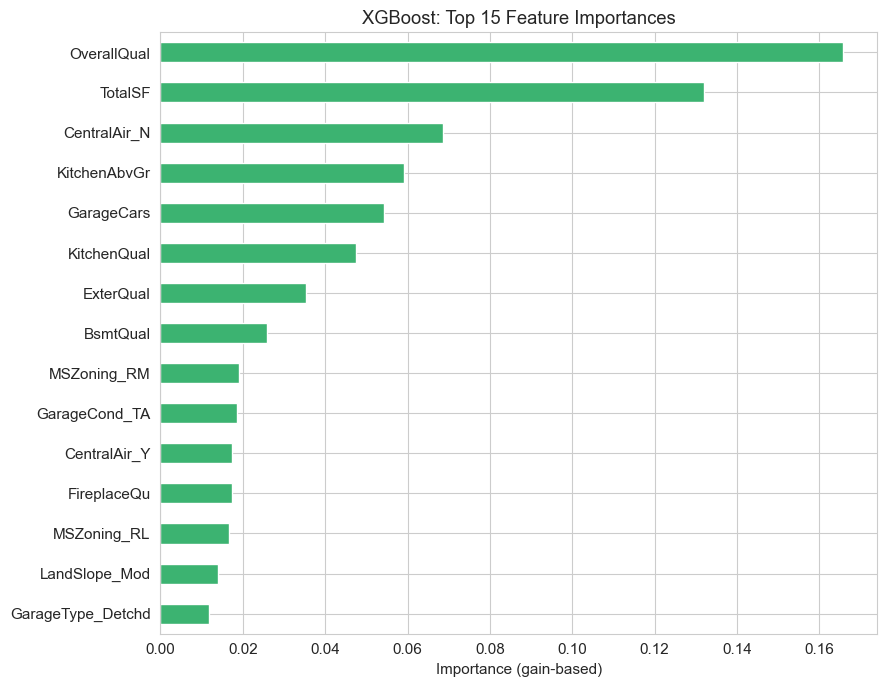

In [33]:
# Top 15 feature importances
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_names)
top15_xgb = xgb_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
top15_xgb.sort_values().plot(kind="barh", color="mediumseagreen")
plt.title("XGBoost: Top 15 Feature Importances")
plt.xlabel("Importance (gain-based)")
plt.tight_layout()
plt.show()


In [34]:
results_df_so_far = pd.DataFrame(results).T
best_model_name_so_far = results_df_so_far["RMSE"].astype(float).idxmin()
print(f"Best-performing model so far (by test RMSE): {best_model_name_so_far}")

model_lookup = {
    "Linear Regression": lin_reg,
    "Ridge": ridge,
    "Lasso": lasso,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}
best_model_so_far = model_lookup[best_model_name_so_far]


Best-performing model so far (by test RMSE): XGBoost


In [35]:
cv_scores = cross_val_score(best_model_so_far, X_train_proc, y_train, cv=5, scoring=rmse_usd_scorer)
cv_rmse_scores = -cv_scores  # scorer returns negative RMSE (sklearn convention: greater_is_better=False)

cv_rmse_mean = cv_rmse_scores.mean()
cv_rmse_std = cv_rmse_scores.std()

print(f"5-Fold CV RMSE for {best_model_name_so_far}: ${cv_rmse_mean:,.0f} +/- ${cv_rmse_std:,.0f}")

results[best_model_name_so_far]["CV_RMSE"] = cv_rmse_mean


5-Fold CV RMSE for XGBoost: $23,917 +/- $4,394


In [36]:
tree_candidates = {"Random Forest": rf_rmse, "XGBoost": xgb_rmse}
model_to_tune = min(tree_candidates, key=tree_candidates.get)
print(f"Tuning: {model_to_tune} (lower test RMSE between the two tree-based models)")

if model_to_tune == "Random Forest":
    base_estimator = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_distributions = {
        "n_estimators": [100, 200, 300, 400, 500],
        "max_depth": [4, 6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }
else:
    base_estimator = XGBRegressor(random_state=42)
    param_distributions = {
        "n_estimators": [200, 300, 400, 500, 600],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 4, 5, 6],
        "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    }

random_search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring=rmse_usd_scorer,
    random_state=42,
    n_jobs=-1,
)

start = time.time()
random_search.fit(X_train_proc, y_train)
tuning_time = time.time() - start

print(f"\nBest parameters found: {random_search.best_params_}")
print(f"Best CV RMSE (3-fold, USD scale): ${-random_search.best_score_:,.0f}")


Tuning: XGBoost (lower test RMSE between the two tree-based models)

Best parameters found: {'subsample': 0.9, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV RMSE (3-fold, USD scale): $23,678


In [37]:
tuned_model = random_search.best_estimator_
y_pred_log = tuned_model.predict(X_test_proc)
tuned_rmse, tuned_mae, tuned_r2, _, tuned_pred_usd = usd_metrics(y_test, y_pred_log)

print(f"Tuned {model_to_tune} (test set, original USD scale)")
print(f"  RMSE : ${tuned_rmse:,.0f}")
print(f"  MAE  : ${tuned_mae:,.0f}")
print(f"  R2   : {tuned_r2:.4f}")

improvement = tree_candidates[model_to_tune] - tuned_rmse
print(f"\nRMSE change vs. untuned {model_to_tune}: ${improvement:,.0f} "
      f"({'improvement' if improvement > 0 else 'no improvement'})")

# Update the results table with the TUNED version of this model,
# since it is now the best-known configuration for it
results[model_to_tune] = {"RMSE": tuned_rmse, "MAE": tuned_mae, "R2": tuned_r2,
                           "CV_RMSE": results[model_to_tune].get("CV_RMSE", np.nan),
                           "Train_Time_s": tuning_time}


Tuned XGBoost (test set, original USD scale)
  RMSE : $19,252
  MAE  : $14,010
  R2   : 0.9329

RMSE change vs. untuned XGBoost: $29 (improvement)


## Step 6: Model Evaluation & Comparison

In [38]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["RMSE", "MAE", "R2", "CV_RMSE", "Train_Time_s"]]
comparison_df = comparison_df.loc[["Linear Regression", "Ridge", "Lasso", "Random Forest", "XGBoost"]]

comparison_df_display = comparison_df.copy()
comparison_df_display["RMSE"] = comparison_df_display["RMSE"].map(lambda x: f"${x:,.0f}")
comparison_df_display["MAE"] = comparison_df_display["MAE"].map(lambda x: f"${x:,.0f}")
comparison_df_display["R2"] = comparison_df_display["R2"].map(lambda x: f"{x:.4f}")
comparison_df_display["CV_RMSE"] = comparison_df_display["CV_RMSE"].map(
    lambda x: f"${x:,.0f}" if pd.notnull(x) else "-")
comparison_df_display["Train_Time_s"] = comparison_df_display["Train_Time_s"].map(lambda x: f"{x:.2f}s")

comparison_df_display


,RMSE,MAE,R2,CV_RMSE,Train_Time_s
Linear Regression,"$23,428","$16,087",0.9006,-,0.02s
Ridge,"$20,583","$14,694",0.9233,-,0.12s
Lasso,"$20,121","$14,683",0.9267,-,0.17s
Random Forest,"$23,161","$16,334",0.9029,-,0.52s
XGBoost,"$19,252","$14,010",0.9329,"$23,917",15.48s


Overall best model: XGBoost  |  RMSE=$19,252  R2=0.9329


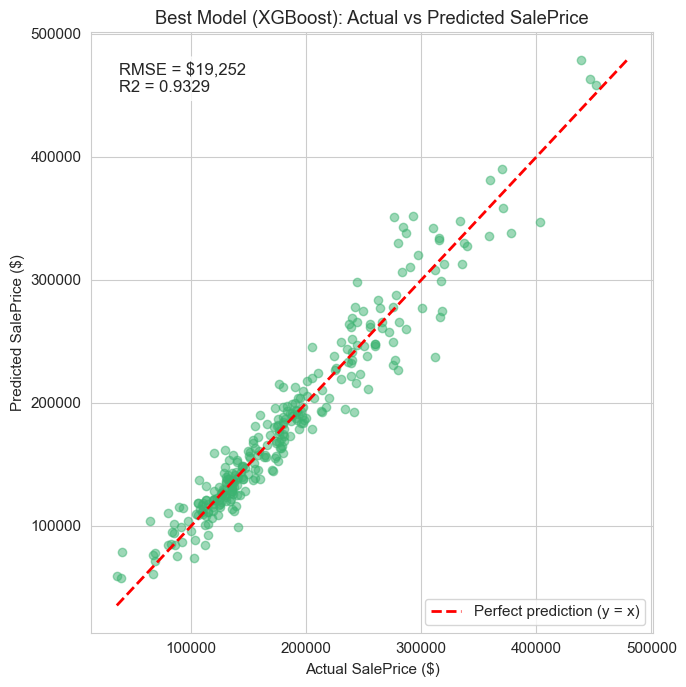

In [39]:
best_model_name = comparison_df["RMSE"].astype(float).idxmin()
best_rmse = comparison_df.loc[best_model_name, "RMSE"]
best_r2 = comparison_df.loc[best_model_name, "R2"]

pred_lookup = {
    "Linear Regression": lin_pred_usd,
    "Ridge": ridge_pred_usd,
    "Lasso": lasso_pred_usd,
    "Random Forest": rf_pred_usd if model_to_tune != "Random Forest" else tuned_pred_usd,
    "XGBoost": xgb_pred_usd if model_to_tune != "XGBoost" else tuned_pred_usd,
}
best_pred_usd = pred_lookup[best_model_name]

print(f"Overall best model: {best_model_name}  |  RMSE=${best_rmse:,.0f}  R2={best_r2:.4f}")

plt.figure(figsize=(7, 7))
plt.scatter(y_test_usd, best_pred_usd, alpha=0.5, color="mediumseagreen")
lims = [min(y_test_usd.min(), best_pred_usd.min()), max(y_test_usd.max(), best_pred_usd.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction (y = x)")
plt.xlabel("Actual SalePrice ($)")
plt.ylabel("Predicted SalePrice ($)")
plt.title(f"Best Model ({best_model_name}): Actual vs Predicted SalePrice")
plt.annotate(f"RMSE = ${best_rmse:,.0f}\nR2 = {best_r2:.4f}",
             xy=(0.05, 0.90), xycoords="axes fraction",
             fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Step 7: Residual Analysis & Model Interpretation

### 7.1 Residual Plots

All residuals below are computed on the **original USD scale** (`Actual − Predicted`) for the
overall best model identified in Step 6.


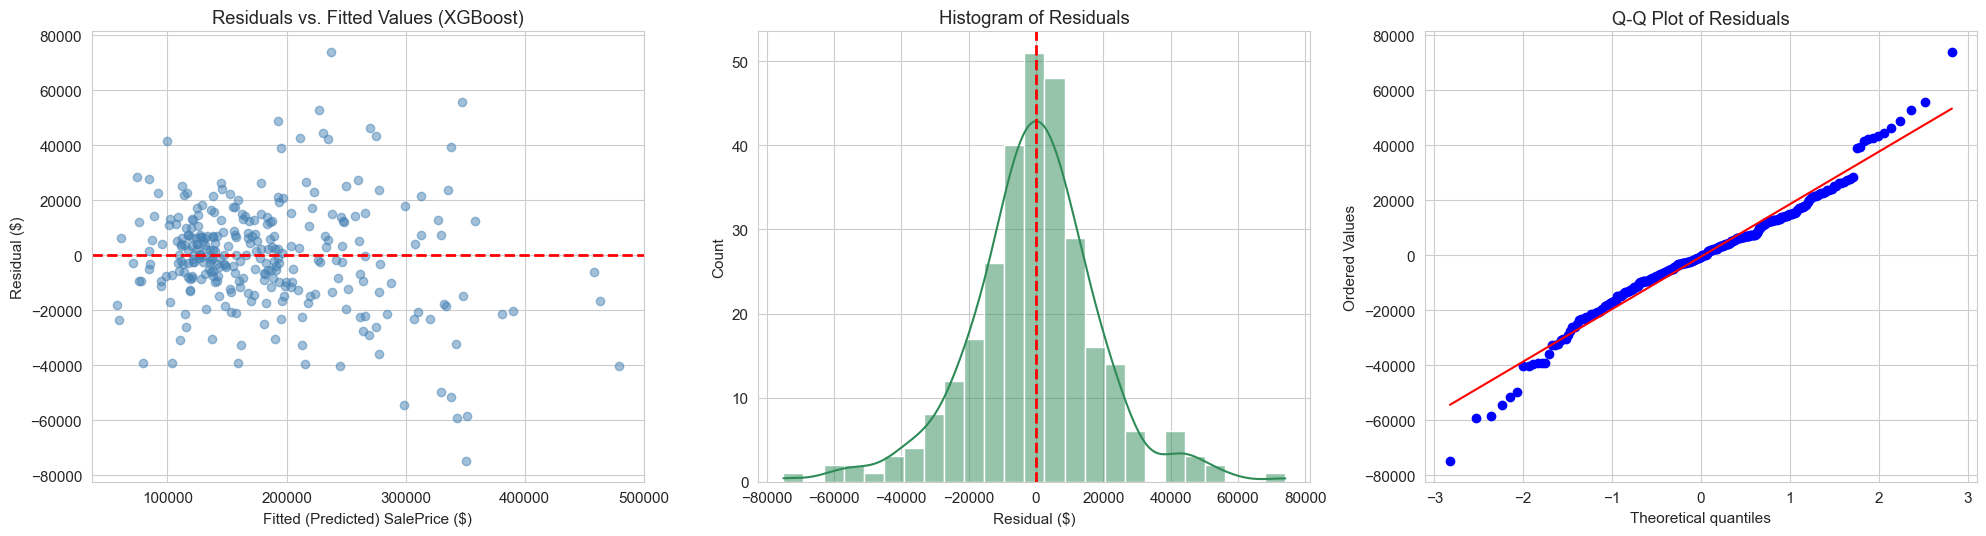

Residual mean : $-538
Residual std  : $19,245
Residual skewness: -0.084
Residual kurtosis: 1.961


In [40]:
residuals = y_test_usd.values - best_pred_usd

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Residuals vs Fitted
axes[0].scatter(best_pred_usd, residuals, alpha=0.5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Fitted (Predicted) SalePrice ($)")
axes[0].set_ylabel("Residual ($)")
axes[0].set_title(f"Residuals vs. Fitted Values ({best_model_name})")

# Histogram of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color="seagreen")
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residual ($)")
axes[1].set_title("Histogram of Residuals")

# Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

print(f"Residual mean : ${residuals.mean():,.0f}")
print(f"Residual std  : ${residuals.std():,.0f}")
print(f"Residual skewness: {pd.Series(residuals).skew():.3f}")
print(f"Residual kurtosis: {pd.Series(residuals).kurt():.3f}")


In [41]:
if best_model_name in ["Random Forest", "XGBoost"]:
    fitted_best_model = tuned_model if model_to_tune == best_model_name else \
        (rf_model if best_model_name == "Random Forest" else xgb_model)
    importance_series = pd.Series(fitted_best_model.feature_importances_, index=feature_names)
    top5_features = importance_series.sort_values(ascending=False).head(5)
else:
    coef_lookup = {"Linear Regression": lin_reg, "Ridge": ridge, "Lasso": lasso}
    coef_series = pd.Series(coef_lookup[best_model_name].coef_, index=feature_names)
    top5_features = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(5)

print(f"Top 5 most impactful features for {best_model_name}:\n")
print(top5_features)


Top 5 most impactful features for XGBoost:

OverallQual    0.168332
ExterQual      0.115266
TotalSF        0.103509
GarageCars     0.051631
KitchenQual    0.049105
dtype: float32


## Step 8: Pipeline, Deployment & GitHub Submission

### 8.1 Save the Final Pipeline

The best-performing model identified in Step 6 (`best_model_name`) is wrapped together with the
Step 3.4 `preprocessor` into a single end-to-end `sklearn.pipeline.Pipeline`, so that a fresh,
raw row of house features (no manual preprocessing required) can be scored directly.


In [42]:
import joblib
from sklearn.pipeline import Pipeline as SkPipeline

# Select the actual fitted model object behind the winning name from Step 6
model_obj_lookup = {
    "Linear Regression": lin_reg,
    "Ridge": ridge,
    "Lasso": lasso,
    "Random Forest": tuned_model if model_to_tune == "Random Forest" else rf_model,
    "XGBoost": tuned_model if model_to_tune == "XGBoost" else xgb_model,
}
best_model_object = model_obj_lookup[best_model_name]

# Combine the already-fitted preprocessing ColumnTransformer with the best model
# into one deployable Pipeline (raw features in -> USD-scale prediction out)
final_pipeline = SkPipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model_object),
])

joblib.dump(final_pipeline, "house_price_model.pkl")
print(f"Saved final pipeline (best model = {best_model_name}) to house_price_model.pkl")


Saved final pipeline (best model = XGBoost) to house_price_model.pkl


In [43]:
loaded_pipeline = joblib.load("house_price_model.pkl")

sample_idx = X_test.index[:5]
sample_X = X_test.loc[sample_idx]
sample_actual_usd = np.expm1(y_test.loc[sample_idx])

# The pipeline predicts in log1p space (since it was trained on log1p(SalePrice));
# reverse the transform to report predictions in real USD.
sample_pred_log = loaded_pipeline.predict(sample_X)
sample_pred_usd = np.expm1(sample_pred_log)

pipeline_test = pd.DataFrame({
    "Actual_SalePrice": sample_actual_usd.values,
    "Predicted_SalePrice": sample_pred_usd,
}, index=sample_idx)
pipeline_test["Abs_Error"] = (pipeline_test["Actual_SalePrice"] - pipeline_test["Predicted_SalePrice"]).abs()

pipeline_test_display = pipeline_test.copy()
for col in pipeline_test_display.columns:
    pipeline_test_display[col] = pipeline_test_display[col].map(lambda x: f"${x:,.0f}")

pipeline_test_display


,Actual_SalePrice,Predicted_SalePrice,Abs_Error
1320,"$190,000","$212,599","$22,599"
836,"$100,000","$95,817","$4,183"
413,"$115,000","$111,001","$3,999"
522,"$159,000","$161,244","$2,244"
1035,"$315,500","$333,913","$18,413"
